<a href="https://colab.research.google.com/github/Abhinav2631/Tweets_Sentiment_Analysis/blob/main/Tweets_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import re
import nltk

In [6]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
df = pd.read_csv("twitter_training.csv", header=None)
df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

In [8]:
df

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [9]:
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,686


In [10]:
print(df['Sentiment'].value_counts())

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [11]:
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r"http\S+|@\S+|#[A-Za-z0-9_]+|[^A-Za-z\s]", "", text)
    text = text.lower()
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

In [12]:
df['Cleaned_Tweet'] = df['Tweet'].apply(clean_text)

In [13]:
le = LabelEncoder()
df['Encoded_Sentiment'] = le.fit_transform(df['Sentiment'])

In [14]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['Cleaned_Tweet']).toarray()
y = df['Encoded_Sentiment']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

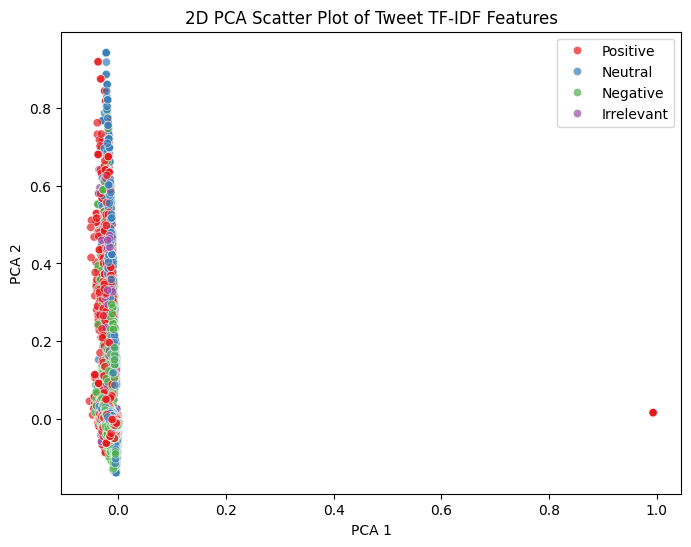

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Sentiment', palette='Set1', alpha=0.7)
plt.title("2D PCA Scatter Plot of Tweet TF-IDF Features")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

In [17]:
df['Tweet_Length'] = df['Tweet'].apply(lambda x: len(str(x).split()))

/tmp/ipython-input-3963492195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Tweet_Length', data=df, palette='Pastel1')


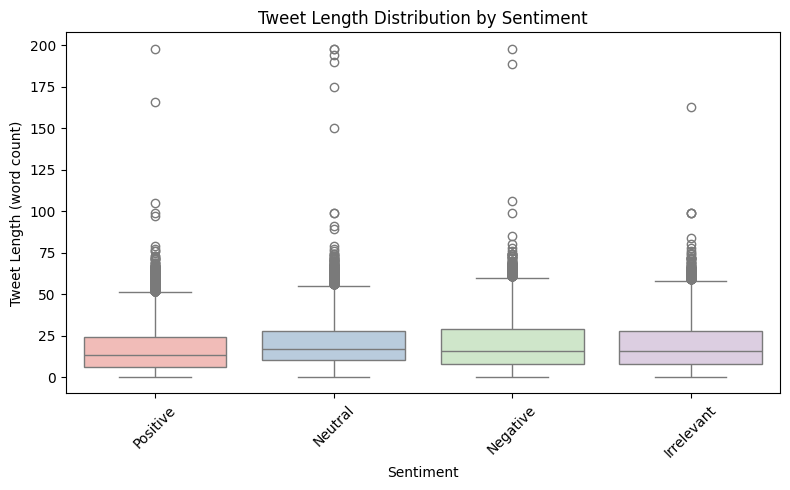

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sentiment', y='Tweet_Length', data=df, palette='Pastel1')
plt.title("Tweet Length Distribution by Sentiment")
plt.ylabel("Tweet Length (word count)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4241384920.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=df['Sentiment'].value_counts().index)


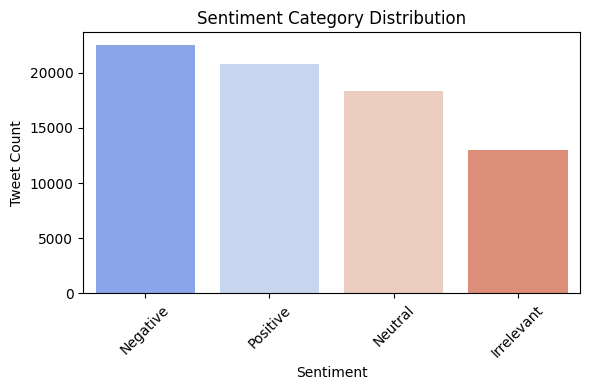

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=df['Sentiment'].value_counts().index)
plt.title("Sentiment Category Distribution")
plt.ylabel("Tweet Count")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

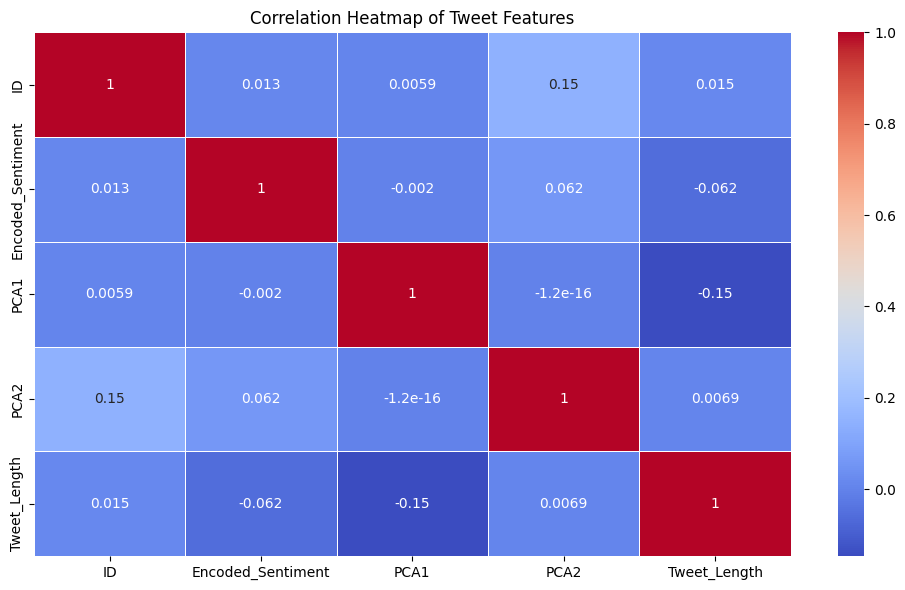

In [20]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Tweet Features")
plt.tight_layout()
plt.show()

In [21]:
corr = df[['Encoded_Sentiment', 'Tweet_Length']].corr()

In [22]:
from sklearn.model_selection import train_test_split

X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.25,
    random_state=42,
    stratify=y_train
)


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.25,
    random_state=42,
    stratify=y_train
)

dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_sample, y_sample)
dt_pred = dt_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, target_names=le.classes_))


Decision Tree Metrics:
Accuracy: 0.3856196023297851
              precision    recall  f1-score   support

  Irrelevant       0.50      0.06      0.10      2592
    Negative       0.34      0.92      0.50      4519
     Neutral       0.66      0.11      0.19      3596
    Positive       0.57      0.24      0.34      4230

    accuracy                           0.39     14937
   macro avg       0.52      0.33      0.28     14937
weighted avg       0.51      0.39      0.31     14937



In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=0.25, random_state=42, stratify=y_train)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_sample, y_sample)
rf_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Accuracy: 0.6815960366874205
              precision    recall  f1-score   support

           0       0.76      0.46      0.57      2592
           1       0.68      0.80      0.73      4519
           2       0.71      0.62      0.66      3596
           3       0.64      0.75      0.69      4230

    accuracy                           0.68     14937
   macro avg       0.70      0.66      0.66     14937
weighted avg       0.69      0.68      0.68     14937



In [25]:
sample_tweets = [
    "I love the new update, it's amazing!",
    "This app keeps crashing. Worst experience ever!",
    "Not sure how I feel about the new feature.",
    "Absolutely terrible customer service.",
    "Flight was delayed but the crew was nice."
]

In [26]:
def clean_text(text):
    text = re.sub(r"http\S+|@\S+|#[A-Za-z0-9_]+|[^A-Za-z\s]", "", text)
    text = text.lower()
    return " ".join([word for word in text.split() if word not in stop_words])
cleaned_samples = [clean_text(tweet) for tweet in sample_tweets]
sample_features = tfidf.transform(cleaned_samples).toarray()

In [27]:
predicted_labels = rf_model.predict(sample_features)
predicted_sentiments = le.inverse_transform(predicted_labels)
for tweet, sentiment in zip(sample_tweets, predicted_sentiments):
    print(f"Tweet: {tweet}\nPredicted Sentiment: {sentiment}\n")

Tweet: I love the new update, it's amazing!
Predicted Sentiment: Positive

Tweet: This app keeps crashing. Worst experience ever!
Predicted Sentiment: Negative

Tweet: Not sure how I feel about the new feature.
Predicted Sentiment: Positive

Tweet: Absolutely terrible customer service.
Predicted Sentiment: Negative

Tweet: Flight was delayed but the crew was nice.
Predicted Sentiment: Positive

